# Variability Analysis for xie21 t-SNE Dataset (FT Model)

This notebook applies the corrected formulas for Generalized Variance and Hierarchical Aggregation.

In [ ]:
from project_utils import *
from project_utils import compute_jaeger_ceiling_xie


In [1]:
import pandas as pd
import numpy as np
import os
import h5py
import warnings
import traceback
from scipy.optimize import minimize_scalar
from joblib import Parallel, delayed
os.environ['R_HOME'] = r'C:\Program Files\R\R-4.4.1'
os.environ["PATH"] += os.pathsep + r"C:\Program Files\R\R-4.4.1\bin\x64"
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
pandas2ri.activate()
importr('lme4')
warnings.filterwarnings('ignore')

In [2]:


import textgrid
import os


def build_token_dict(std_data, speakers, audio_dir, df):
    # This will return a dictionary:
    # tokens[unit][talker_idx][sent_idx] = [list of feature matrices (T, D)]
    # where unit is 'Sentence', 'Word', or 'Phoneme'
    
    # 1. Initialize dictionaries
    num_speakers = len(speakers)
    tokens = {
        'Sentence': {spk_idx: [[] for _ in range(32)] for spk_idx in range(num_speakers)},
        'Word': {spk_idx: [[] for _ in range(32)] for spk_idx in range(num_speakers)},
        'Phoneme': {spk_idx: [[] for _ in range(32)] for spk_idx in range(num_speakers)}
    }
    
    keywords_dict = get_keywords_dict(df)
    keywords_list = list(keywords_dict.values())
    
    set1_list = [0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16]
    set2_list = [17,18,19,20,21,22,24,25,26,27,28,29,30,31,37,40]
    combined_set = set1_list + set2_list
    
    # Process each speaker and sentence
    for spk_idx, spk in enumerate(speakers):
        tg_path = os.path.join(audio_dir, f"{spk}.TextGrid")
        if not os.path.exists(tg_path): continue
        
        tg = textgrid.TextGrid.fromFile(tg_path)
        tg_sentence = tg[0]
        # Fix maxTime for sentences as per original logic
        for idx_tg, item in enumerate(tg_sentence):
            if item.mark != "":
                if idx_tg > 0:
                    tg_sentence[idx_tg - 1].maxTime = tg_sentence[idx_tg].minTime
        tg_sentence = [item for item in tg_sentence if item.mark != ""]
        tg_sentence = [tg_sentence[i] for i in combined_set]
        
        tg_word = [item for item in tg[1] if item.mark != "" and item.mark != "sp"]
        tg_phoneme = tg[2] if len(tg) > 2 else tg[1]
        
        for sent_idx, each_sentence in enumerate(tg_sentence):
            sentence_total_length = each_sentence.maxTime - each_sentence.minTime
            sent_feat = std_data[sent_idx][spk_idx]
            num_frames = sent_feat.shape[0]
            
            if num_frames == 0 or sentence_total_length <= 0: continue
            
            # Sentence level
            tokens['Sentence'][spk_idx][sent_idx].append(sent_feat)
            
            # Word and Phoneme level
            keywords = keywords_list[sent_idx] if sent_idx < len(keywords_list) else []
            for kw in keywords:
                word_start_time = None
                word_end_time = None
                for each_word_tg in tg_word:
                    if each_word_tg.mark.lower() == kw.lower():
                        if each_word_tg.minTime >= each_sentence.minTime and each_word_tg.maxTime <= each_sentence.maxTime:
                            word_start_time = each_word_tg.minTime
                            word_end_time = each_word_tg.maxTime
                            break
                if word_start_time is None: continue
                
                # Slicing for word
                word_cut_start = word_start_time - each_sentence.minTime
                word_cut_end = word_end_time - each_sentence.minTime
                w_start_frame = max(0, min(round(num_frames * word_cut_start / sentence_total_length), num_frames - 1))
                w_end_frame = max(w_start_frame + 1, min(round(num_frames * word_cut_end / sentence_total_length), num_frames))
                
                word_feat = sent_feat[w_start_frame:w_end_frame]
                tokens['Word'][spk_idx][sent_idx].append(word_feat)
                
                # Phonemes for this word
                for each_phone_tg in tg_phoneme:
                    if each_phone_tg.minTime >= word_start_time and each_phone_tg.maxTime <= word_end_time:
                        phone_label = each_phone_tg.mark
                        if phone_label == "" or phone_label.lower() in ["sil", "sp"]: continue
                        
                        phone_cut_start = each_phone_tg.minTime - each_sentence.minTime
                        phone_cut_end = each_phone_tg.maxTime - each_sentence.minTime
                        p_start_frame = max(0, min(round(num_frames * phone_cut_start / sentence_total_length), num_frames - 1))
                        p_end_frame = max(p_start_frame + 1, min(round(num_frames * phone_cut_end / sentence_total_length), num_frames))
                        
                        phone_feat = sent_feat[p_start_frame:p_end_frame]
                        if phone_feat.shape[0] > 0:
                            tokens['Phoneme'][spk_idx][sent_idx].append(phone_feat)
                            
    return tokens

In [3]:
def _minkowski_distance(x, y, tau):
    diff = np.abs(x - y)
    return np.sum(diff ** tau, axis=-1) ** (1.0 / tau)


def find_talker_idx(talker, talker_index_map):
    for spk, idx in talker_index_map.items():
        if spk.startswith(talker):
            return idx
    return -1

def compute_variability_for_condition(training_talkers, sent_range, tokens_for_unit, talker_index_map, tau, calculation_type):
    if calculation_type == 'WithinToken':
        token_variances = []
        for each_talker in training_talkers:
            talker_idx = find_talker_idx(each_talker, talker_index_map)
            if talker_idx == -1: continue
            for sent_idx in sent_range:
                for token_frames in tokens_for_unit[talker_idx][sent_idx]:
                    if token_frames.shape[0] == 0: continue
                    token_mean = np.mean(token_frames, axis=0)
                    frame_dists = _minkowski_distance(token_frames, token_mean, tau)
                    token_variances.append(np.mean(frame_dists))
        return np.mean(token_variances) if token_variances else np.nan

    elif calculation_type == 'WithinType':
        type_variances = []
        for sent_idx in sent_range:
            max_tokens = 0
            for each_talker in training_talkers:
                talker_idx = find_talker_idx(each_talker, talker_index_map)
                if talker_idx == -1: continue
                max_tokens = max(max_tokens, len(tokens_for_unit[talker_idx][sent_idx]))
            
            for token_pos in range(max_tokens):
                token_means = []
                for each_talker in training_talkers:
                    talker_idx = find_talker_idx(each_talker, talker_index_map)
                    if talker_idx == -1: continue
                    if token_pos < len(tokens_for_unit[talker_idx][sent_idx]):
                        frames = tokens_for_unit[talker_idx][sent_idx][token_pos]
                        if frames.shape[0] > 0:
                            token_means.append(np.mean(frames, axis=0))
                if token_means:
                    type_mean = np.mean(token_means, axis=0)
                    token_dists = [_minkowski_distance(tm, type_mean, tau) for tm in token_means]
                    type_variances.append(np.mean(token_dists))
        return np.mean(type_variances) if type_variances else np.nan

    elif calculation_type == 'BetweenType':
        type_means = []
        for sent_idx in sent_range:
            max_tokens = 0
            for each_talker in training_talkers:
                talker_idx = find_talker_idx(each_talker, talker_index_map)
                if talker_idx == -1: continue
                max_tokens = max(max_tokens, len(tokens_for_unit[talker_idx][sent_idx]))
            
            for token_pos in range(max_tokens):
                token_means = []
                for each_talker in training_talkers:
                    talker_idx = find_talker_idx(each_talker, talker_index_map)
                    if talker_idx == -1: continue
                    if token_pos < len(tokens_for_unit[talker_idx][sent_idx]):
                        frames = tokens_for_unit[talker_idx][sent_idx][token_pos]
                        if frames.shape[0] > 0:
                            token_means.append(np.mean(frames, axis=0))
                if token_means:
                    type_means.append(np.mean(token_means, axis=0))
        if not type_means: return np.nan
        global_mean = np.mean(type_means, axis=0)
        type_dists = [_minkowski_distance(tm, global_mean, tau) for tm in type_means]
        return np.mean(type_dists)

    elif calculation_type == 'Order':
        token_variances = []
        for each_talker in training_talkers:
            talker_idx = find_talker_idx(each_talker, talker_index_map)
            if talker_idx == -1: continue
            for sent_idx in sent_range:
                for token_frames in tokens_for_unit[talker_idx][sent_idx]:
                    if token_frames.shape[0] < 2: continue
                    dists = _minkowski_distance(token_frames[1:], token_frames[:-1], tau)
                    token_variances.append(np.mean(dists))
        return np.mean(token_variances) if token_variances else np.nan


In [4]:
def run_glmm_variability_logic(tau, train_df, test_df, purpose='optimize'):
    try:
        from rpy2.robjects import pandas2ri
        import rpy2.robjects as ro
        from rpy2.robjects.packages import importr
        pandas2ri.activate()
        lme4 = importr('lme4')
        
        train_work = train_df.copy()
        if 'TrainingTalkerID1' not in train_work.columns:
            train_work['TrainingTalkerID1'] = train_work['TrainingTalkerID'].apply(lambda x: ",".join(sorted(str(x).split(", "))))
        
        train_agg = train_work.groupby(
            ['Keyword', 'Condition2', 'TrainingTalkerID1', 'TestTalkerID', 'SentenceID'], as_index=False
        ).agg(
            IsCorrect=('IsCorrect', 'mean'), variability=('variability', 'mean'),
            numCorrect=('IsCorrect', lambda x: (x == 1).sum()), numIncorrect=('IsCorrect', lambda x: (x == 0).sum())
        )
        train_agg = train_agg.dropna(subset=['variability'])

        train_sd = train_agg['variability'].std()
        if train_sd == 0 or pd.isna(train_sd): return 999.0 if purpose == 'optimize' else None

        ro.globalenv['r_train'] = pandas2ri.py2rpy(train_agg)
        ro.r('''
            r_train$SentenceID   <- factor(r_train$SentenceID)
            r_train$Keyword      <- factor(r_train$Keyword)
            r_train$TestTalkerID <- factor(r_train$TestTalkerID)
            model_train <- glmer(
                cbind(numCorrect, numIncorrect) ~ 1 + variability + (1 | SentenceID / Keyword) + (1 | TestTalkerID),
                data=r_train, family=binomial(link="logit"), control=glmerControl(optimizer="bobyqa", optCtrl=list(maxfun=10000)))
            z_train  <- summary(model_train)$coefficients[2, 3]
            ll_train <- as.numeric(logLik(model_train))
        ''')
        z_train = ro.globalenv['z_train'][0]
        if purpose == 'optimize': return -z_train

        if purpose == 'evaluate' and test_df is not None:
            test_work = test_df.copy()
            if 'TrainingTalkerID1' not in test_work.columns:
                test_work['TrainingTalkerID1'] = test_work['TrainingTalkerID'].apply(lambda x: ",".join(sorted(str(x).split(", "))))

            test_agg = test_work.groupby(['Keyword', 'Condition2', 'TrainingTalkerID1', 'TestTalkerID', 'SentenceID'], as_index=False).agg(
                IsCorrect=('IsCorrect', 'mean'), variability=('variability', 'mean'),
                numCorrect=('IsCorrect', lambda x: (x == 1).sum()), numIncorrect=('IsCorrect', lambda x: (x == 0).sum())
            )
            test_agg = test_agg.dropna(subset=['variability'])
            ro.globalenv['r_test'] = pandas2ri.py2rpy(test_agg)
            ro.r('''
                r_test$SentenceID   <- factor(r_test$SentenceID)
                r_test$Keyword      <- factor(r_test$Keyword)
                r_test$TestTalkerID <- factor(r_test$TestTalkerID)
                model_test <- glmer(
                    cbind(numCorrect, numIncorrect) ~ 1 + variability + (1 | SentenceID / Keyword) + (1 | TestTalkerID),
                    data=r_test, family=binomial(link="logit"), control=glmerControl(optimizer="bobyqa", optCtrl=list(maxfun=10000)))
                ll_test <- as.numeric(logLik(model_test))
                z_test  <- summary(model_test)$coefficients[2, 3]
            ''')
            return {
                'z_train': z_train, 'z_test': ro.globalenv['z_test'][0],
                'poll_train': ro.globalenv['ll_train'][0] / (train_agg['numCorrect'].sum() + train_agg['numIncorrect'].sum()),
                'poll_test': ro.globalenv['ll_test'][0] / (test_agg['numCorrect'].sum() + test_agg['numIncorrect'].sum()),
            }
    except Exception as e:
        import traceback
        traceback.print_exc()
        return 999.0 if purpose == 'optimize' else None
    return None

def process_single_layer_variability(layer_key, df_final, audio_dir, h5_path, method, tokens, speakers):
    try:
        folds = sorted(df_final['fold'].unique())
        diagnostic_results, best_taus = [], []

        for f in folds:
            train_idx = df_final['fold'] != f
            test_idx = df_final['fold'] == f
            
            def objective(tau_val):
                train_df = df_final[train_idx].copy()
                df_var = precompute_layer_variability(train_df, tokens, speakers, tau_val, method)
                return run_glmm_variability_logic(tau_val, df_var, None, 'optimize')
            
            res = minimize_scalar(objective, bounds=(0.5, 4.0), method='bounded')
            best_tau = res.x
            best_taus.append(best_tau)

            train_df = df_final[train_idx].copy()
            test_df  = df_final[test_idx].copy()
            train_var = precompute_layer_variability(train_df, tokens, speakers, best_tau, method)
            test_var  = precompute_layer_variability(test_df, tokens, speakers, best_tau, method)
            
            metrics = run_glmm_variability_logic(best_tau, train_var, test_var, 'evaluate')
            if metrics:
                opt = (metrics['poll_train'] - metrics['poll_test']) / abs(metrics['poll_train']) if metrics['poll_train'] != 0 else 0
                diagnostic_results.append({
                    'layer': layer_key, 'fold': f, 'type': 'diagnostic', 'tau': best_tau,
                    'z_train': metrics['z_train'], 'z_test':  metrics['z_test'],
                    'poll_train': metrics['poll_train'], 'poll_test':  metrics['poll_test'],
                    'optimism': opt,
                })

        mean_tau = np.mean(best_taus)
        corrected_results = []
        for f in folds:
            train_df = df_final[df_final['fold'] != f].copy()
            test_df  = df_final[df_final['fold'] == f].copy()
            train_var = precompute_layer_variability(train_df, tokens, speakers, mean_tau, method)
            test_var  = precompute_layer_variability(test_df, tokens, speakers, mean_tau, method)
            
            metrics = run_glmm_variability_logic(mean_tau, train_var, test_var, 'evaluate')
            if metrics:
                opt = (metrics['poll_train'] - metrics['poll_test']) / abs(metrics['poll_train']) if metrics['poll_train'] != 0 else 0
                corrected_results.append({
                    'layer': layer_key, 'fold': f, 'type': 'corrected', 'tau': mean_tau,
                    'z_train': metrics['z_train'], 'z_test':  metrics['z_test'],
                    'poll_train': metrics['poll_train'], 'poll_test':  metrics['poll_test'],
                    'optimism': opt,
                })

        results_df = pd.DataFrame(diagnostic_results + corrected_results)
        full_var_df = precompute_layer_variability(df_final, tokens, speakers, mean_tau, method)
        return results_df, layer_key, full_var_df
        
    except Exception as e:
        import traceback
        return f"EXCEPTION in {layer_key}: {e}\n{traceback.format_exc()}"

def run_variability_pipeline(layers_list, df_final, audio_dir, h5_path, method, n_jobs=-1):
    import time
    print(f"Starting {method} analysis for {len(layers_list)} layers...")
    start = time.time()
    
    def worker_func(layer_key):
        import traceback
        try:
            layer_data, speakers = load_single_layer_from_h5(h5_path, audio_dir, layer_key)
            std_data = standardization(layer_data)
            tokens = build_token_dict(std_data, speakers, audio_dir, df_final)
            return process_single_layer_variability(layer_key, df_final, audio_dir, h5_path, method, tokens, speakers)
        except Exception as e:
            return f"EXCEPTION in {layer_key} wrapper: {e}\n{traceback.format_exc()}"
    
    tasks = [delayed(worker_func)(k) for k in layers_list]
    raw_results = Parallel(n_jobs=n_jobs, verbose=5)(tasks)

    valid_results, var_frames = [], {}
    for item in raw_results:
        if isinstance(item, str):
            print(item)
            continue
        if item is None: continue
        res_df, layer_key, var_df = item
        if res_df is not None and not res_df.empty: valid_results.append(res_df)
        if var_df is not None: 
            var_df = var_df[['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID', 'variability']].drop_duplicates().reset_index(drop=True)
            var_frames[layer_key] = var_df

    all_layers_results = pd.concat(valid_results, ignore_index=True) if valid_results else pd.DataFrame()
    df_all = df_final.copy()
    for layer_key, var_df in var_frames.items():
        df_all = df_all.merge(var_df.rename(columns={'variability': layer_key}), on=['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID'], how='left')

    print(f"Done in {(time.time() - start):.2f}s")
    return all_layers_results, df_all

In [5]:
from sklearn.model_selection import StratifiedKFold

audio_dir = r"../data/raw_data/xie_liu_jaeger21/sound_stimuli"
human_result_path = r"../data/raw_data/xie_liu_jaeger21/X21-exposure-test-behavioral-data.xlsx"

# 1. 准备 Human Data
human_result = pd.read_excel(human_result_path)
human_result_1a = human_result[human_result["Experiment"]=="1a"].copy()
human_result_1a["TrainingTalkerID1"] = human_result_1a["TrainingTalkerID"].astype(str).apply(lambda x: ",".join(sorted(x.split(", "))) if pd.notna(x) else x)

df = human_result_1a.copy()
participants = df[['WorkerID', 'TrainingTestSet', 'Condition2', 'TestTalkerID']].drop_duplicates().reset_index(drop=True)
participants['combined_key'] = participants['TrainingTestSet'].astype(str) + "_" + participants['Condition2'].astype(str) + "_" + participants['TestTalkerID'].astype(str)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
participants['fold'] = -1
for fold_idx, (train_index, test_index) in enumerate(skf.split(participants, participants['combined_key'])):
    participants.loc[test_index, 'fold'] = fold_idx + 1
df_final = df.merge(participants[['WorkerID', 'fold']], on='WorkerID', how='left')

# 2. 自动检测并获取所有的 Layer 名称
h5_path = r"../data/features/xie21_tsne_3d_ft.h5"

with h5py.File(h5_path, 'r') as h5f:
    root_keys = list(h5f.keys())
    if 'cnn_6' in root_keys or 'tr_12' in root_keys:
        layers_list = root_keys
    else:
        first_spk = root_keys[0]
        first_sent = list(h5f[first_spk].keys())[0]
        layers_list = list(h5f[first_spk][first_sent].keys())

print(f"Found {len(layers_list)} layers to process: {layers_list}")

METHODS = [
    'WithinTokenSentence', 'WithinTokenWord', 'WithinTokenPhoneme',
    'WithinTypeSentence', 'WithinTypeWord', 'WithinTypePhoneme',
    'BetweenTypeSentence', 'BetweenTypeWord', 'BetweenTypePhoneme',
    'OrderSentence', 'OrderWord', 'OrderPhoneme'
]

for method in METHODS:
    print(f"\n=======================================================")
    print(f"Running GLMM Analysis for method: {method}")
    print(f"=======================================================")
    glmm_res, df_vals = run_variability_pipeline(layers_list, df_final, audio_dir, h5_path, method, n_jobs=-1)
    
    if not glmm_res.empty:
        glmm_res.to_csv(f"results/xie21_tsne_ft_variability_glmm_{method}.csv", index=False)
        df_vals.to_csv(f"results/xie21_tsne_ft_variability_values_{method}.csv", index=False)
        print(f"Results saved for {method}")

Found 18 layers to process: ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_0', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_2', 'tr_20', 'tr_22', 'tr_24', 'tr_4', 'tr_6', 'tr_8']

Running GLMM Analysis for method: WithinTokenSentence
Starting WithinTokenSentence analysis for 18 layers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:    1.7s remaining:    9.1s
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:    1.8s remaining:    2.9s
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:    1.9s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:    2.0s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:    2.1s finished


EXCEPTION in cnn_2: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_minimize.py", line 945, in minimize_scalar
    res = _minimize_scalar_bounded(fun, bounds, args, **options)
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_optimize.py", line 2269, in _minimize_scalar_bounded
    fx = func(x, *args)
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 81, in objective
NameError: name 'precompute_layer_variability' is not defined

EXCEPTION in cnn_3: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\si

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:    0.9s remaining:    5.1s
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:    1.2s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:    1.2s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:    1.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:    1.4s finished


EXCEPTION in cnn_2: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_minimize.py", line 945, in minimize_scalar
    res = _minimize_scalar_bounded(fun, bounds, args, **options)
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_optimize.py", line 2269, in _minimize_scalar_bounded
    fx = func(x, *args)
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 81, in objective
NameError: name 'precompute_layer_variability' is not defined

EXCEPTION in cnn_3: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\si

...

EXCEPTION in cnn_2: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_minimize.py", line 945, in minimize_scalar
    res = _minimize_scalar_bounded(fun, bounds, args, **options)
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_optimize.py", line 2269, in _minimize_scalar_bounded
    fx = func(x, *args)
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 81, in objective
NameError: name 'precompute_layer_variability' is not defined

EXCEPTION in cnn_3: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\si

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:    0.5s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:    0.6s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:    0.8s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:    0.8s finished


EXCEPTION in cnn_2: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_minimize.py", line 945, in minimize_scalar
    res = _minimize_scalar_bounded(fun, bounds, args, **options)
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_optimize.py", line 2269, in _minimize_scalar_bounded
    fx = func(x, *args)
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 81, in objective
NameError: name 'precompute_layer_variability' is not defined

EXCEPTION in cnn_3: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\si

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:    0.5s remaining:    2.7s
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:    0.5s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:    0.8s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:    0.8s finished


EXCEPTION in cnn_2: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_minimize.py", line 945, in minimize_scalar
    res = _minimize_scalar_bounded(fun, bounds, args, **options)
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\site-packages\scipy\optimize\_optimize.py", line 2269, in _minimize_scalar_bounded
    fx = func(x, *args)
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 81, in objective
NameError: name 'precompute_layer_variability' is not defined

EXCEPTION in cnn_3: name 'precompute_layer_variability' is not defined
Traceback (most recent call last):
  File "C:\Users\Alex\AppData\Local\Temp\ipykernel_11652\275632867.py", line 84, in process_single_layer_variability
  File "C:\Users\Alex\anaconda3\envs\BayesPCN\lib\si

In [6]:
glmm_res

""


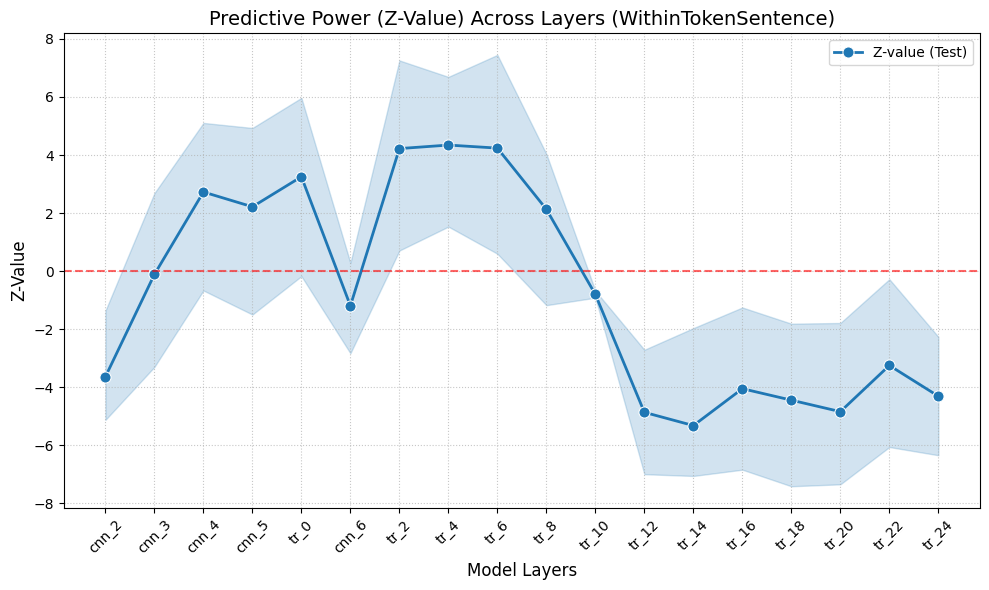

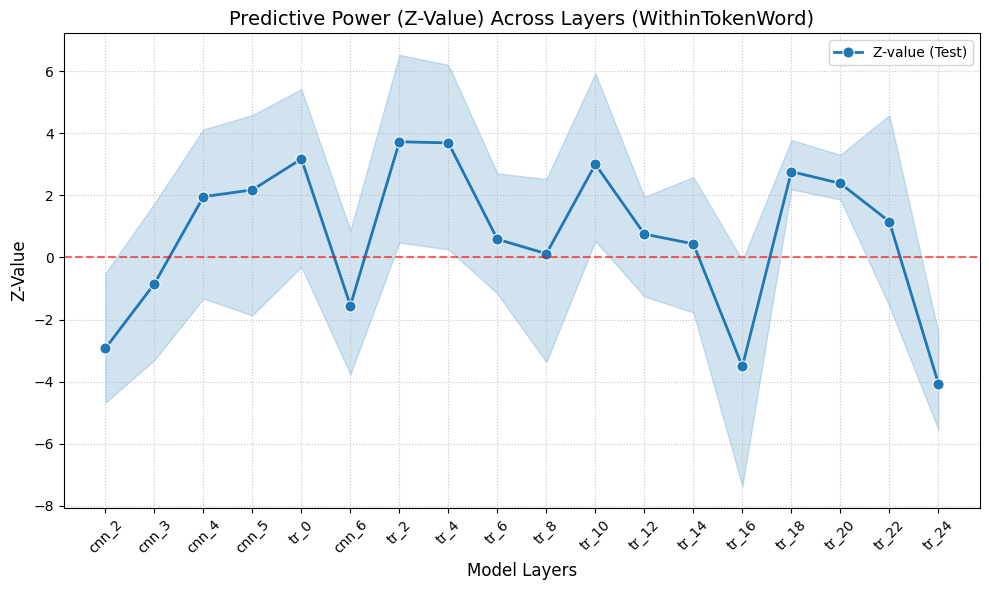

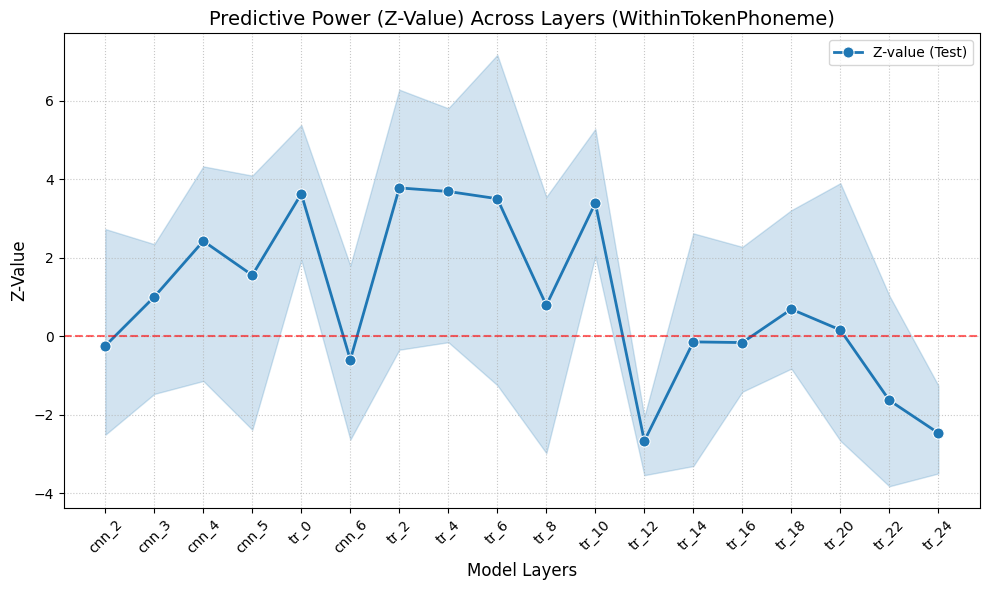

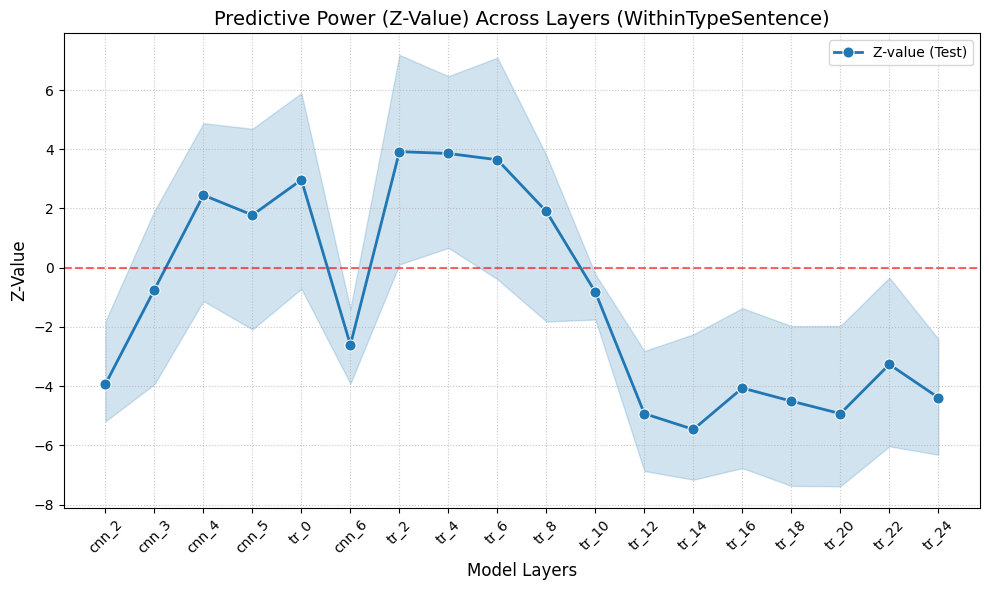

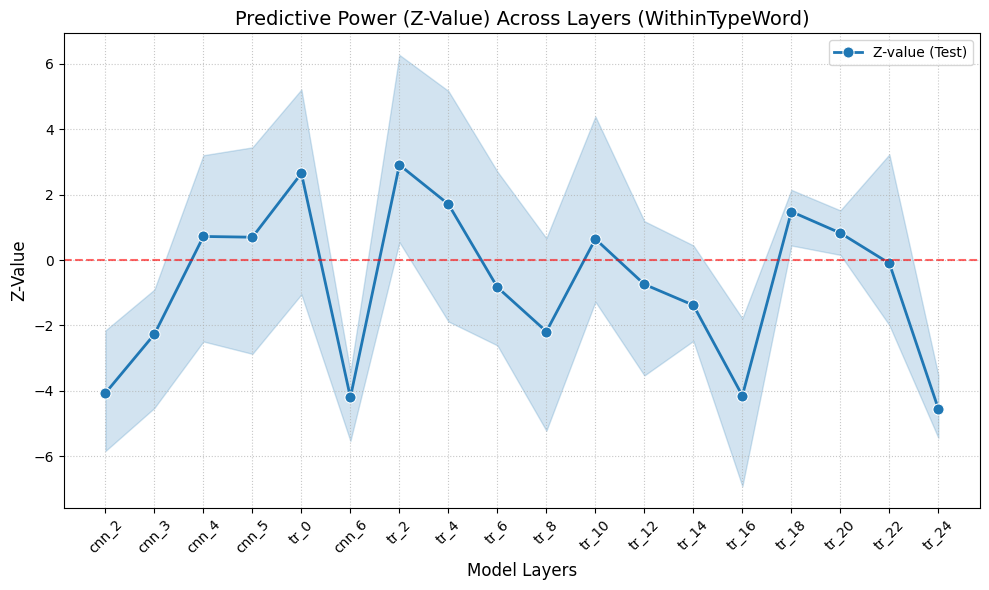

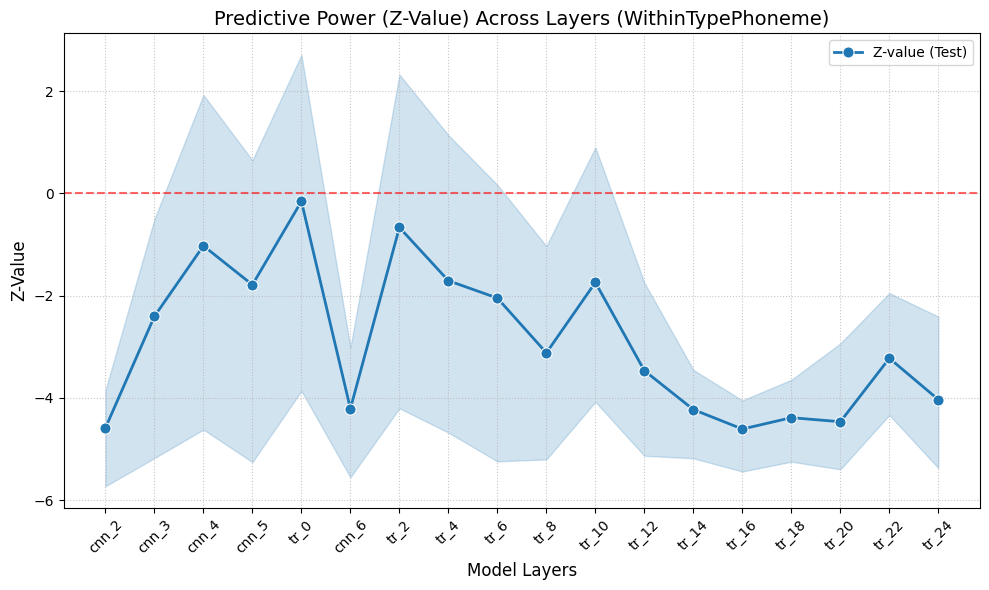

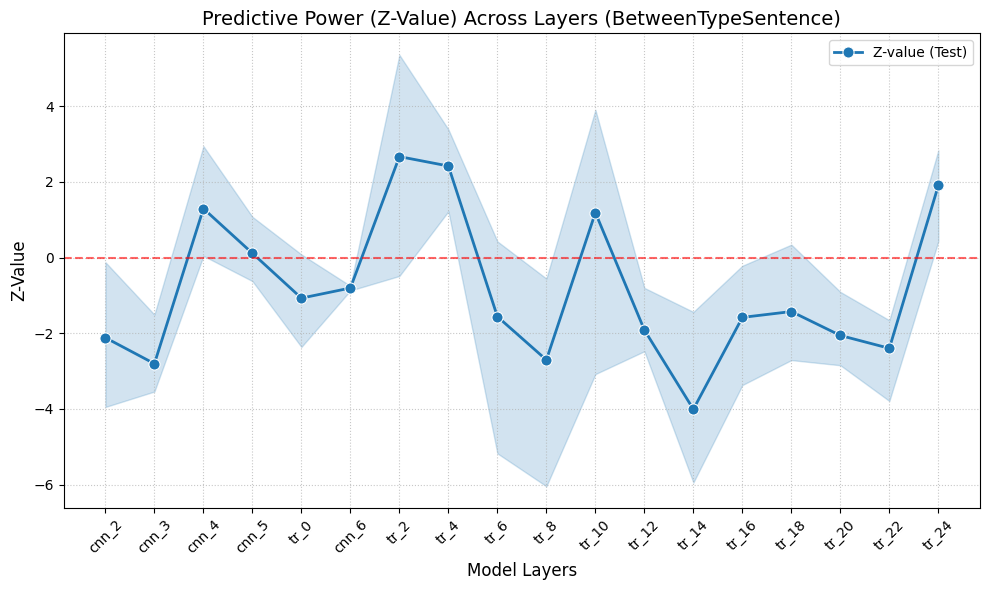

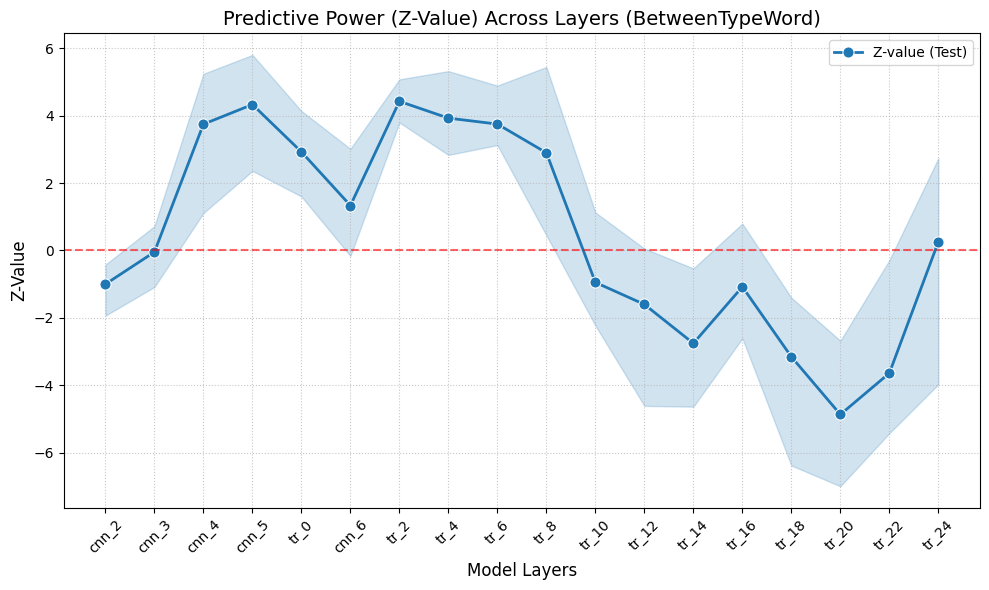

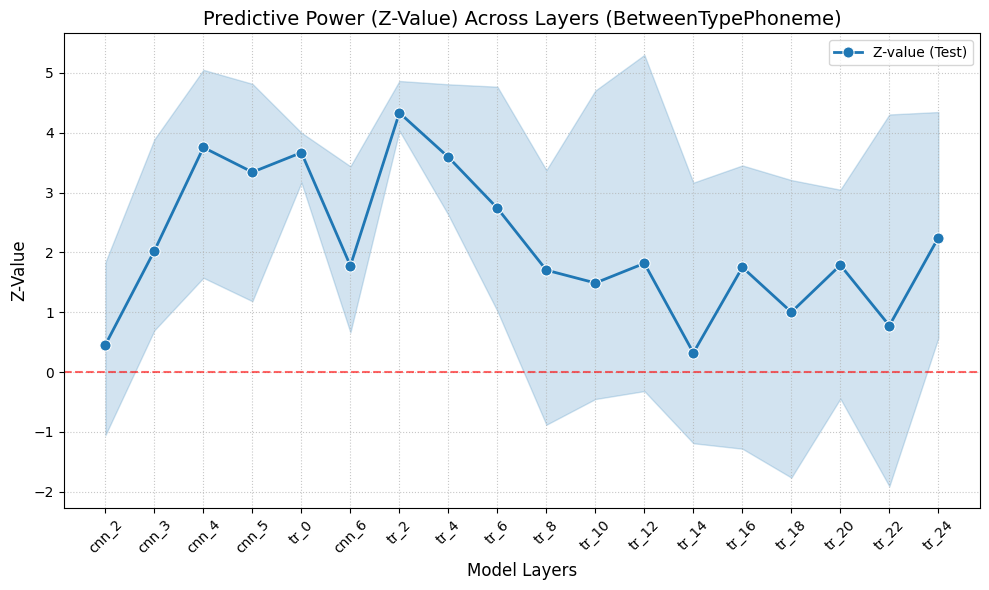

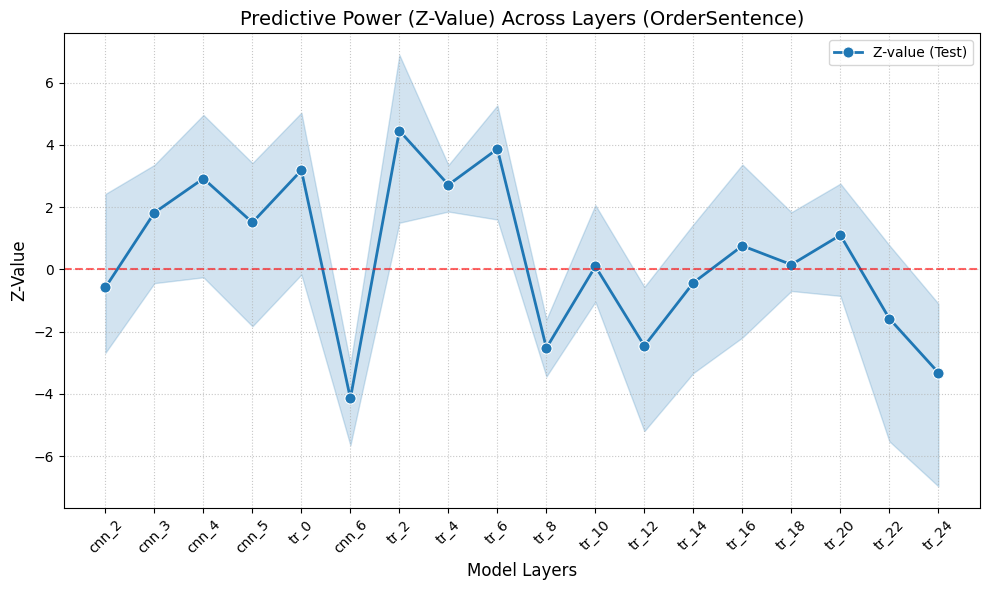

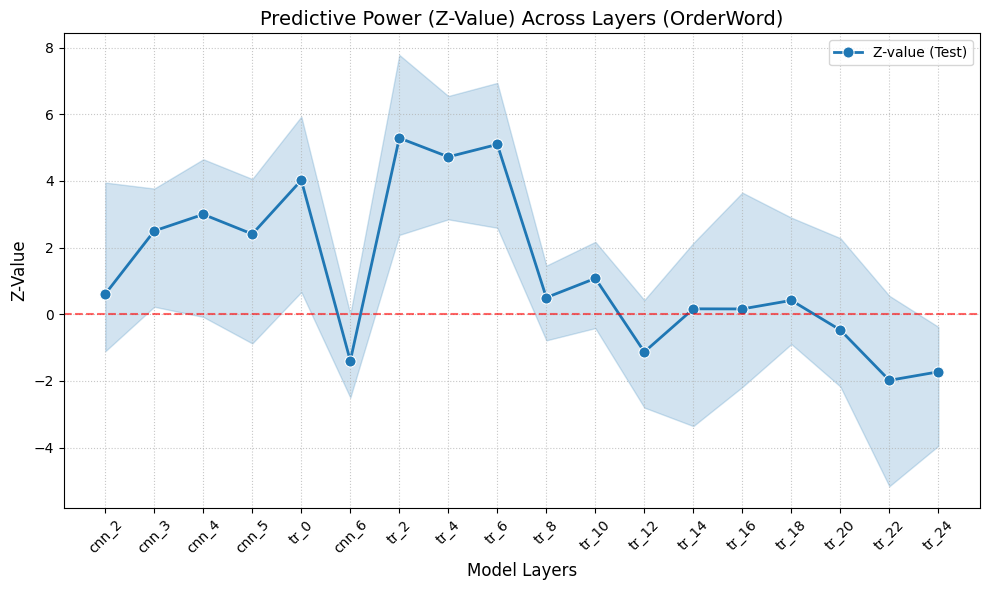

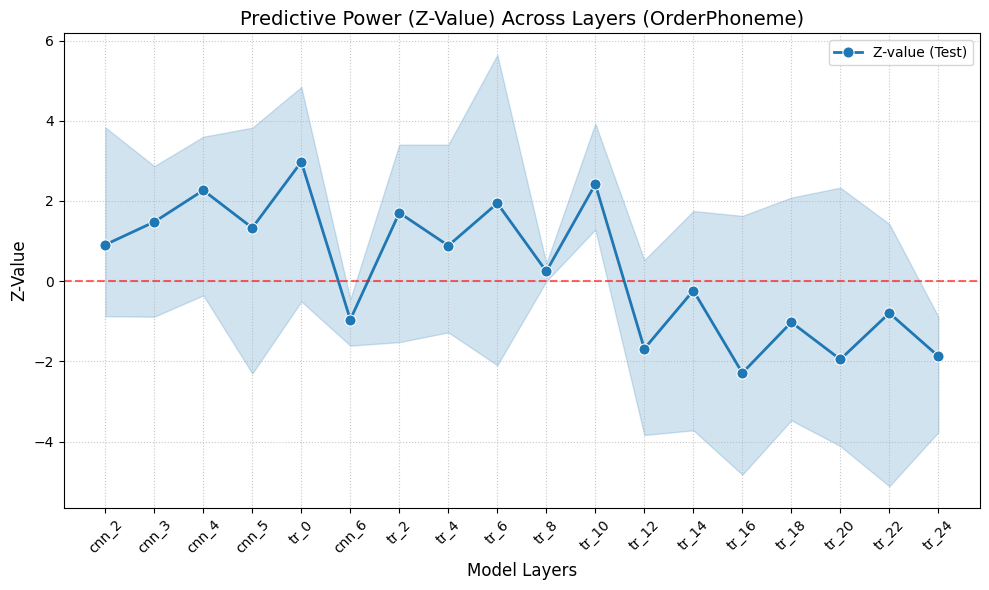

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你刚刚跑完了 WithinSentence 方法
METHODS = [
    'WithinTokenSentence', 'WithinTokenWord', 'WithinTokenPhoneme',
    'WithinTypeSentence', 'WithinTypeWord', 'WithinTypePhoneme',
    'BetweenTypeSentence', 'BetweenTypeWord', 'BetweenTypePhoneme',
    'OrderSentence', 'OrderWord', 'OrderPhoneme'
]
for method in METHODS:
    df_res = pd.read_csv(f"results/xie21_tsne_ft_variability_glmm_{method}.csv")
    

    # 过滤出 corrected 的真实结果 (过滤掉 diagnostic 找参数的过程)
    df_plot = df_res[df_res['type'] == 'corrected'].copy()

    # 为了按顺序排列网络层，我们需要提取其中的数字
    # layer 名称例如: 'cnn_2', 'cnn_3', ..., 'cnn_6' 或者 'tr_1', 'tr_12'
    def extract_layer_num(layer_name):
        if 'cnn' in layer_name:
            return int(layer_name.split('_')[1])
        elif 'tr' in layer_name:
            return 6 + int(layer_name.split('_')[1]) # Transformer 层排在 CNN 后面
        return 0

    df_plot['layer_order'] = df_plot['layer'].apply(extract_layer_num)
    df_plot = df_plot.sort_values('layer_order')

    plt.figure(figsize=(10, 6))
    # 绘制折线图，x 轴是层名称，y 轴是测试集上的 Z-value
    sns.lineplot(data=df_plot, x='layer', y='z_test', marker='o', markersize=8, linewidth=2, label='Z-value (Test)')

    # 添加一条 y=0 的基准线
    plt.axhline(0, color='red', linestyle='--', alpha=0.6)

    plt.title(f"Predictive Power (Z-Value) Across Layers ({method})", fontsize=14)
    plt.xlabel("Model Layers", fontsize=12)
    plt.ylabel("Z-Value", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Archived Script: `compare_tsne.py`
The following code was migrated from a standalone `.py` script during project reorganization.

In [ ]:
import pickle
import h5py
import numpy as np
import os
import glob

old_pkl_path = r'C:\Users\Alex\Desktop\Pycharm\cross-talker-ASR\July\hubert_Nygaard_all_tr_dict.pkl'

# Find the nygaard19_tsne_3d.h5 file
base_dir = r'C:\Users\Alex\Documents\GitHub\Similarity-based inferences predict cross-talker generalization during human speech perception'
h5_files = glob.glob(base_dir + '../data/features/nygaard19_tsne_3d.h5', recursive=True)
if not h5_files:
    print("Cannot find nygaard19_tsne_3d.h5!")
    exit(1)
new_h5_path = h5_files[0]
print("Found new H5 at:", new_h5_path)

print("Loading old pickle file...")
with open(old_pkl_path, 'rb') as f:
    old_data = pickle.load(f)

print("Opening new h5 file...")
new_data = h5py.File(new_h5_path, 'r')

layer_to_check = 24
layer_key_new = f'tr_{layer_to_check}'
layer_key_old = layer_to_check

old_layer = old_data[layer_key_old]
new_layer = new_data[layer_key_new]

# Find a common speaker and word
speakers = list(old_layer.keys())
spk = speakers[0]
words = list(old_layer[spk].keys())
word = words[0]

print(f"\nComparing Speaker: {spk}, Word: {word}")

old_feat = old_layer[spk][word]
new_feat = new_layer[spk][word][:]

print(f"Old Feature Shape: {old_feat.shape}")
print(f"New Feature Shape: {new_feat.shape}")

print("\nOld Feature Mean:", np.mean(old_feat, axis=0))
print("Old Feature Std:", np.std(old_feat, axis=0))

print("New Feature Mean:", np.mean(new_feat, axis=0))
print("New Feature Std:", np.std(new_feat, axis=0))

# Sample comparison
print(f"Sample Old Feature: {old_feat[0]}")
print(f"Sample New Feature: {new_feat[0]}")

new_data.close()



### Archived Script: `eval_tsne_inst_norm.py`
The following code was migrated from a standalone `.py` script during project reorganization.

In [ ]:
import pandas as pd
import json
import h5py
import os

with open('nygaard_glmm.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

code_cells = [c['source'] for c in nb['cells'] if c['cell_type'] == 'code']
code_text = ""
for cell in code_cells:
    code_text += "".join(cell) + "\n"

exec_globals = {}
exec_code = []
for line in code_text.split('\n'):
    if line.startswith('if os.path.exists(EXCEL_PATH):'):
        break
    exec_code.append(line)

exec('\n'.join(exec_code), exec_globals)

run_full_nygaard_analysis = exec_globals['run_full_nygaard_analysis']

EXCEL_PATH = "../data/raw_data/alexander_nygaard19/AN19-exposure-test-behavioral-data.xlsx"
df_behavioral = pd.read_excel(EXCEL_PATH)

print("Evaluating Inst-Norm TSNE Features...")
df_tsne_inst = run_full_nygaard_analysis(
    df_behavioral, 
    "../data/features/nygaard19_tsne_3d_random_inst_norm.h5",
    distance_type="minkowski", 
    tau=2.0, 
    alpha=0.1, 
    n_jobs=30
)

if not df_tsne_inst.empty:
    df_tsne_inst.to_csv('results/nygaard19_glmm_results_hubert_inst_norm.csv', index=False)
    print("results/Saved nygaard19_glmm_results_hubert_inst_norm.csv")

print("Evaluating Inst-Norm FT TSNE Features...")
df_tsne_ft_inst = run_full_nygaard_analysis(
    df_behavioral, 
    "../data/features/nygaard19_tsne_3d_ft_random_inst_norm.h5",
    distance_type="minkowski", 
    tau=2.0, 
    alpha=0.1, 
    n_jobs=30
)

if not df_tsne_ft_inst.empty:
    df_tsne_ft_inst.to_csv('results/nygaard19_glmm_results_hubert_ft_inst_norm.csv', index=False)
    print("results/Saved nygaard19_glmm_results_hubert_ft_inst_norm.csv")

print("Evaluation Complete!")



### Archived Script: `plot_inst_norm_tsne.py`
The following code was migrated from a standalone `.py` script during project reorganization.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df_tsne = pd.read_csv('results/nygaard19_glmm_results_hubert_inst_norm.csv')
df_tsne_ft = pd.read_csv('results/nygaard19_glmm_results_hubert_ft_inst_norm.csv')

df_tsne['Condition'] = 't-SNE (Inst-Norm)'
df_tsne_ft['Condition'] = 'FT t-SNE (Inst-Norm)'

df_all = pd.concat([df_tsne, df_tsne_ft])
df_all = df_all[df_all['type'] == 'corrected']

# Ceiling
# In nygaard_glmm, ceil mean is calculated from baseline. Let's use 14.31 from previous
ceiling_vals = compute_jaeger_ceiling_xie(df_final)
ceil_mean = np.mean(ceiling_vals)
ceil_sem  = np.std(ceiling_vals, ddof=1) / np.sqrt(len(ceiling_vals))
df_all['percent_ceiling'] = (df_all['z_test'].abs() / ceil_mean) * 100

layer_order = [
    'cnn_1', 'cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'cnn_7',
    'tr_0', 'tr_2', 'tr_4', 'tr_6', 'tr_8', 'tr_10', 'tr_12',
    'tr_14', 'tr_16', 'tr_18', 'tr_20', 'tr_22', 'tr_24'
]

layers_present = df_all['layer'].unique()
layer_order = [l for l in layer_order if l in layers_present]

plt.figure(figsize=(12, 6))
sns.pointplot(
    data=df_all,
    x='layer',
    y='percent_ceiling',
    hue='Condition',
    order=layer_order,
    dodge=True,
    markers=['o', 's'],
    linestyles=['-', '--']
)

# Plot Baseline
mfcc_z = 11.31
strf_z = 11.13
mfcc_pc = (mfcc_z / ceil_mean) * 100
strf_pc = (strf_z / ceil_mean) * 100

plt.axhline(y=mfcc_pc, color='darkorange', linestyle='--', label='MFCC (Inst-Norm)')
plt.axhline(y=strf_pc, color='forestgreen', linestyle='-.', label='STRF (Inst-Norm)')

plt.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Behavioral Ceiling')
plt.axhline(y=(1.96 / ceil_mean) * 100, color='gray', linestyle=':', label='Significance Threshold (p=0.05)')

plt.xticks(rotation=45)
plt.ylabel('% Behavioral Ceiling (Z-score)')
plt.title('Performance of Instance-Normalized t-SNE Features across HuBERT Layers')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/nygaard19_inst_norm_tsne_comparison.png', dpi=300)
print("plots/Saved plot to nygaard19_inst_norm_tsne_comparison.png")



### Archived Script: `xie_variability_tsne.py`
The following code was migrated from a standalone `.py` script during project reorganization.

In [ ]:
#!/usr/bin/env python
# coding: utf-8

# # Variability Analysis for xie21 t-SNE Dataset (FT Model)
# 
# This notebook applies the corrected formulas for Generalized Variance and Hierarchical Aggregation.

# In[20]:


import pandas as pd
import numpy as np
import os
import h5py
import warnings
import traceback
from scipy.optimize import minimize_scalar
from joblib import Parallel, delayed
os.environ['R_HOME'] = r'C:\Program Files\R\R-4.4.1'
os.environ["PATH"] += os.pathsep + r"C:\Program Files\R\R-4.4.1\bin\x64"
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
pandas2ri.activate()
warnings.filterwarnings('ignore')


# In[21]:





# In[22]:


def _generalized_variance(diff, tau):
    if diff.ndim == 1:
        return np.sum(np.abs(diff) ** tau)
    return np.sum(np.abs(diff) ** tau, axis=1)


def find_talker_idx(talker, talker_index_map):
    for spk, idx in talker_index_map.items():
        if spk.startswith(talker):
            return idx
    return -1

def compute_variability_for_condition(training_talkers, sent_range, reduced_data, talker_index_map, tau, method):
    if method == 'WithinSentence':
        token_variances = []
        for each_talker in training_talkers:
            talker_idx = find_talker_idx(each_talker, talker_index_map)
            if talker_idx == -1: continue
            for sent_idx in sent_range:
                sent_frames = reduced_data[sent_idx][talker_idx]
                if sent_frames.shape[0] == 0: continue
                sent_mean = np.mean(sent_frames, axis=0)
                frame_vars = _generalized_variance(sent_frames - sent_mean, tau)
                token_variances.append(np.mean(frame_vars))
        if token_variances: return np.mean(token_variances)
        else: return np.nan

    elif method == 'BetweenSentence':
        type_means = []
        for sent_idx in sent_range:
            token_means = []
            for each_talker in training_talkers:
                talker_idx = find_talker_idx(each_talker, talker_index_map)
                if talker_idx == -1: continue
                sent_frames = reduced_data[sent_idx][talker_idx]
                if sent_frames.shape[0] > 0:
                    token_means.append(np.mean(sent_frames, axis=0))
            if token_means:
                type_means.append(np.mean(token_means, axis=0))
        if not type_means: return np.nan
        global_mean = np.mean(type_means, axis=0)
        type_vars = [_generalized_variance(tm - global_mean, tau) for tm in type_means]
        return np.mean(type_vars)

    elif method == 'Sentence_Order':
        token_variances = []
        for each_talker in training_talkers:
            talker_idx = find_talker_idx(each_talker, talker_index_map)
            if talker_idx == -1: continue
            for sent_idx in sent_range:
                sent_frames = reduced_data[sent_idx][talker_idx]
                if sent_frames.shape[0] < 2: continue
                diffs = sent_frames[1:] - sent_frames[:-1]
                frame_pair_vars = _generalized_variance(diffs, tau)
                token_variances.append(np.mean(frame_pair_vars))
        if token_variances: return np.mean(token_variances)
        else: return np.nan

def precompute_layer_variability(df, reduced_data, speakers, tau, method):
    talker_index_map = {spk: idx for idx, spk in enumerate(speakers)}
    unique_conditions = df[['TrainingTalkerID', 'TrainingTestSet']].drop_duplicates()
    var_map = {}
    for row in unique_conditions.itertuples(index=False):
        tr_id = row.TrainingTalkerID
        tr_set = str(row.TrainingTestSet)
        if pd.isna(tr_id): continue
        
        training_talkers = get_training_paths(tr_id)
        if tr_set.startswith("set1"):
            sent_range = range(16)
        else:
            sent_range = range(16, 32)
            
        var_val = compute_variability_for_condition(training_talkers, sent_range, reduced_data, talker_index_map, tau, method)
        var_map[(tr_id, tr_set)] = var_val
        
    rows = []
    for row in df.itertuples(index=False):
        var_val = var_map.get((getattr(row, 'TrainingTalkerID'), str(getattr(row, 'TrainingTestSet'))), np.nan)
        rows.append({
            'Keyword': getattr(row, 'Keyword'), 'Condition2': getattr(row, 'Condition2'),
            'TrainingTalkerID': getattr(row, 'TrainingTalkerID'), 'TestTalkerID': getattr(row, 'TestTalkerID'),
            'SentenceID': getattr(row, 'SentenceID'), 'IsCorrect': getattr(row, 'IsCorrect'),
            'variability': var_val, 'fold': getattr(row, 'fold')
        })
    return pd.DataFrame(rows)


# In[23]:


def run_glmm_variability_logic(tau, train_df, test_df, purpose='optimize'):
    try:
        train_work = train_df.copy()
        if 'TrainingTalkerID1' not in train_work.columns:
            train_work['TrainingTalkerID1'] = train_work['TrainingTalkerID'].apply(lambda x: ",".join(sorted(x.split(", "))))
        
        train_agg = train_work.groupby(
            ['Keyword', 'Condition2', 'TrainingTalkerID1', 'TestTalkerID', 'SentenceID'], as_index=False
        ).agg(
            IsCorrect=('IsCorrect', 'mean'), variability=('variability', 'mean'),
            numCorrect=('IsCorrect', lambda x: (x == 1).sum()), numIncorrect=('IsCorrect', lambda x: (x == 0).sum())
        )
        train_agg = train_agg.dropna(subset=['variability'])

        train_sd = train_agg['variability'].std()
        if train_sd == 0 or pd.isna(train_sd): return 999.0 if purpose == 'optimize' else None

        ro.globalenv['r_train'] = pandas2ri.py2rpy(train_agg)
        ro.r("""
            r_train$SentenceID   <- factor(r_train$SentenceID)
            r_train$Keyword      <- factor(r_train$Keyword)
            r_train$TestTalkerID <- factor(r_train$TestTalkerID)
            model_train <- glmer(
                cbind(numCorrect, numIncorrect) ~ 1 + variability + (1 | SentenceID / Keyword) + (1 | TestTalkerID),
                data=r_train, family=binomial(link="logit"), control=glmerControl(optimizer="bobyqa", optCtrl=list(maxfun=10000)))
            z_train  <- summary(model_train)$coefficients[2, 3]
            ll_train <- as.numeric(logLik(model_train))
        """)
        z_train = ro.globalenv['z_train'][0]
        if purpose == 'optimize': return -z_train

        if purpose == 'evaluate' and test_df is not None:
            test_work = test_df.copy()
            if 'TrainingTalkerID1' not in test_work.columns:
                test_work['TrainingTalkerID1'] = test_work['TrainingTalkerID'].apply(lambda x: ",".join(sorted(x.split(", "))))

            test_agg = test_work.groupby(['Keyword', 'Condition2', 'TrainingTalkerID1', 'TestTalkerID', 'SentenceID'], as_index=False).agg(
                IsCorrect=('IsCorrect', 'mean'), variability=('variability', 'mean'),
                numCorrect=('IsCorrect', lambda x: (x == 1).sum()), numIncorrect=('IsCorrect', lambda x: (x == 0).sum())
            )
            test_agg = test_agg.dropna(subset=['variability'])
            ro.globalenv['r_test'] = pandas2ri.py2rpy(test_agg)
            ro.r("""
                r_test$SentenceID   <- factor(r_test$SentenceID)
                r_test$Keyword      <- factor(r_test$Keyword)
                r_test$TestTalkerID <- factor(r_test$TestTalkerID)
                model_test <- glmer(
                    cbind(numCorrect, numIncorrect) ~ 1 + variability + (1 | SentenceID / Keyword) + (1 | TestTalkerID),
                    data=r_test, family=binomial(link="logit"), control=glmerControl(optimizer="bobyqa", optCtrl=list(maxfun=10000)))
                ll_test <- as.numeric(logLik(model_test))
                z_test  <- summary(model_test)$coefficients[2, 3]
            """)
            return {
                'z_train': z_train, 'z_test': ro.globalenv['z_test'][0],
                'poll_train': ro.globalenv['ll_train'][0] / (train_agg['numCorrect'].sum() + train_agg['numIncorrect'].sum()),
                'poll_test': ro.globalenv['ll_test'][0] / (test_agg['numCorrect'].sum() + test_agg['numIncorrect'].sum()),
            }
    except Exception:
        return 999.0 if purpose == 'optimize' else None
    return None

def process_single_layer_variability(layer_key, df_final, audio_dir, h5_path, method):
    try:
        layer_data, speakers = load_single_layer_from_h5(h5_path, audio_dir, layer_key)
        std_data = standardization(layer_data)
        folds = sorted(df_final['fold'].unique())
        diagnostic_results, best_taus = [], []

        for f in folds:
            train_idx = df_final['fold'] != f
            test_idx = df_final['fold'] == f
            
            def objective(tau_val):
                train_df = df_final[train_idx].copy()
                df_var = precompute_layer_variability(train_df, std_data, speakers, tau_val, method)
                return run_glmm_variability_logic(tau_val, df_var, None, 'optimize')
            
            res = minimize_scalar(objective, bounds=(0.5, 4.0), method='bounded')
            best_tau = res.x
            best_taus.append(best_tau)

            train_df = df_final[train_idx].copy()
            test_df  = df_final[test_idx].copy()
            train_var = precompute_layer_variability(train_df, std_data, speakers, best_tau, method)
            test_var  = precompute_layer_variability(test_df, std_data, speakers, best_tau, method)
            
            metrics = run_glmm_variability_logic(best_tau, train_var, test_var, 'evaluate')
            if metrics:
                diagnostic_results.append({
                    'layer': layer_key, 'fold': f, 'type': 'diagnostic', 'tau': best_tau,
                    'z_train': metrics['z_train'], 'z_test':  metrics['z_test'],
                    'poll_train': metrics['poll_train'], 'poll_test':  metrics['poll_test'],
                    'optimism': (metrics['poll_train'] - metrics['poll_test']) / abs(metrics['poll_train']),
                })

        mean_tau = np.mean(best_taus)
        corrected_results = []
        for f in folds:
            train_df = df_final[df_final['fold'] != f].copy()
            test_df  = df_final[df_final['fold'] == f].copy()
            train_var = precompute_layer_variability(train_df, std_data, speakers, mean_tau, method)
            test_var  = precompute_layer_variability(test_df, std_data, speakers, mean_tau, method)
            
            metrics = run_glmm_variability_logic(mean_tau, train_var, test_var, 'evaluate')
            if metrics:
                corrected_results.append({
                    'layer': layer_key, 'fold': f, 'type': 'corrected', 'tau': mean_tau,
                    'z_train': metrics['z_train'], 'z_test':  metrics['z_test'],
                    'poll_train': metrics['poll_train'], 'poll_test':  metrics['poll_test'],
                    'optimism': (metrics['poll_train'] - metrics['poll_test']) / abs(metrics['poll_train']),
                })

        results_df = pd.DataFrame(diagnostic_results + corrected_results)
        full_var_df = precompute_layer_variability(df_final, std_data, speakers, mean_tau, method)
        return results_df, layer_key, full_var_df
        
    except Exception as e:
        return f"EXCEPTION in {layer_key}: {e}\n{traceback.format_exc()}"

def run_variability_pipeline(layers_list, df_final, audio_dir, h5_path, method, n_jobs=-1):
    import time
    print(f"Starting {method} analysis for {len(layers_list)} layers...")
    start = time.time()
    
    tasks = [delayed(process_single_layer_variability)(k, df_final, audio_dir, h5_path, method) for k in layers_list]
    raw_results = Parallel(n_jobs=n_jobs, verbose=5)(tasks)

    valid_results, var_frames = [], {}
    for item in raw_results:
        if isinstance(item, str):
            print(item)
            continue
        if item is None: continue
        res_df, layer_key, var_df = item
        if res_df is not None and not res_df.empty: valid_results.append(res_df)
        if var_df is not None: 
            var_df = var_df[['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID', 'variability']].drop_duplicates().reset_index(drop=True)
            var_frames[layer_key] = var_df

    all_layers_results = pd.concat(valid_results, ignore_index=True) if valid_results else pd.DataFrame()
    df_all = df_final.copy()
    for layer_key, var_df in var_frames.items():
        df_all = df_all.merge(var_df.rename(columns={'variability': layer_key}), on=['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID'], how='left')

    print(f"Done in {(time.time() - start):.2f}s")
    return all_layers_results, df_all


# In[24]:


from sklearn.model_selection import StratifiedKFold

audio_dir = r"../data/raw_data/xie_liu_jaeger21/sound_stimuli"
human_result_path = r"../data/raw_data/xie_liu_jaeger21/X21-exposure-test-behavioral-data.xlsx"

# 1. 准备 Human Data
human_result = pd.read_excel(human_result_path)
human_result_1a = human_result[human_result["Experiment"]=="1a"].copy()
human_result_1a["TrainingTalkerID1"] = human_result_1a["TrainingTalkerID"].astype(str).apply(lambda x: ",".join(sorted(x.split(", "))) if pd.notna(x) else x)

df = human_result_1a.copy()
participants = df[['WorkerID', 'TrainingTestSet', 'Condition2', 'TestTalkerID']].drop_duplicates().reset_index(drop=True)
participants['combined_key'] = participants['TrainingTestSet'].astype(str) + "_" + participants['Condition2'].astype(str) + "_" + participants['TestTalkerID'].astype(str)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
participants['fold'] = -1
for fold_idx, (train_index, test_index) in enumerate(skf.split(participants, participants['combined_key'])):
    participants.loc[test_index, 'fold'] = fold_idx + 1
df_final = df.merge(participants[['WorkerID', 'fold']], on='WorkerID', how='left')

# 2. 自动检测并获取所有的 Layer 名称
h5_path = r"../data/features/xie21_tsne_3d_ft.h5"

with h5py.File(h5_path, 'r') as h5f:
    root_keys = list(h5f.keys())
    if 'cnn_6' in root_keys or 'tr_12' in root_keys:
        layers_list = root_keys
    else:
        first_spk = root_keys[0]
        first_sent = list(h5f[first_spk].keys())[0]
        layers_list = list(h5f[first_spk][first_sent].keys())

print(f"Found {len(layers_list)} layers to process: {layers_list}")

METHODS = ['BetweenSentence', 'WithinSentence', 'Sentence_Order']

for method in METHODS:
    print(f"\n=======================================================")
    print(f"Running GLMM Analysis for method: {method}")
    print(f"=======================================================")
    glmm_res, df_vals = run_variability_pipeline(layers_list, df_final, audio_dir, h5_path, method, n_jobs=-1)
    
    if not glmm_res.empty:
        glmm_res.to_csv(f"results/xie21_tsne_ft_variability_glmm_{method}.csv", index=False)
        df_vals.to_csv(f"results/xie21_tsne_ft_variability_values_{method}.csv", index=False)
        print(f"Results saved for {method}")


# In[26]:


glmm_res


# In[25]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你刚刚跑完了 WithinSentence 方法
method = "WithinSentence"
df_res = pd.read_csv(f"results/xie21_tsne_ft_variability_glmm_{method}.csv")

# 过滤出 corrected 的真实结果 (过滤掉 diagnostic 找参数的过程)
df_plot = df_res[df_res['type'] == 'corrected'].copy()

# 为了按顺序排列网络层，我们需要提取其中的数字
# layer 名称例如: 'cnn_2', 'cnn_3', ..., 'cnn_6' 或者 'tr_1', 'tr_12'
def extract_layer_num(layer_name):
    if 'cnn' in layer_name:
        return int(layer_name.split('_')[1])
    elif 'tr' in layer_name:
        return 6 + int(layer_name.split('_')[1]) # Transformer 层排在 CNN 后面
    return 0

df_plot['layer_order'] = df_plot['layer'].apply(extract_layer_num)
df_plot = df_plot.sort_values('layer_order')

plt.figure(figsize=(10, 6))
# 绘制折线图，x 轴是层名称，y 轴是测试集上的 Z-value
sns.lineplot(data=df_plot, x='layer', y='z_test', marker='o', markersize=8, linewidth=2, label='Z-value (Test)')

# 添加一条 y=0 的基准线
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.title(f"Predictive Power (Z-Value) Across Layers ({method})", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Z-Value", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


